# Setup

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns

## Import and read the csv data file.

In [5]:
credit_df = pd.read_csv('credit.csv')

In [6]:
print(credit_df.shape)

(1000, 17)


In [7]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

In [8]:
credit_df['default'] = credit_df['default'].map({'no': 0, 'yes': 1})

# Separate features (X) and target (y)
X = credit_df.drop('default', axis=1)
y = credit_df['default']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Encoding Features and Modeling

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

from sklearn import set_config
set_config(display="diagram")

In [10]:
numerical_features = ['months_loan_duration', 'amount', 'age']

ordinal_features = ['percent_of_income', 'years_at_residence', 'existing_loans_count', 'dependents']

nominal_features = X.select_dtypes(include=['object']).columns.tolist()

In [11]:
print(f"Numerical (no scaling): {numerical_features}")
print(f"Ordinal Categorical: {ordinal_features}")
print(f"Nominal Categorical: {nominal_features}")

Numerical (no scaling): ['months_loan_duration', 'amount', 'age']
Ordinal Categorical: ['percent_of_income', 'years_at_residence', 'existing_loans_count', 'dependents']
Nominal Categorical: ['checking_balance', 'credit_history', 'purpose', 'savings_balance', 'employment_duration', 'other_credit', 'housing', 'job', 'phone']


In [12]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier

In [13]:
# Ordinal transformer: Encodes ordinal categories to numbers
ordinal_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Nominal transformer: One-hot encodes nominal categories, drops first for multicollinearity
nominal_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features), # Numerical features pass through unchanged
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_features)
    ]
)

In [14]:
from sklearn.base import clone

def build_pipeline(model):
    return Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('clf', model)
    ])

In [15]:
def run_grid_search(pipeline, param_grid, X_train, y_train, cv=5, scoring='accuracy'):
    gs = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    gs.fit(X_train, y_train)
    print(f"Best params: {gs.best_params_}")
    print(f"Best CV score: {gs.best_score_:.4f}")
    return gs

In [16]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds))

In [17]:
def collect_metrics(name, model, X_test, y_test):
    preds = model.predict(X_test)
    return {
        'Model':       name,
        'Accuracy':    accuracy_score(y_test, preds),
        'Precision':   precision_score(y_test, preds),
        'Recall':      recall_score(y_test, preds),
        'F1-Score':    f1_score(y_test, preds),
    }

## Running Cross Validation

In [18]:
configs = {
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'clf__n_estimators': [100, 200], 'clf__max_depth': [None, 10, 20], 'clf__min_samples_split': [2, 5]}
    ),
    'Bagging': (
        BaggingClassifier(random_state=42),
        {'clf__n_estimators': [10, 50, 100], 'clf__max_samples': [0.5, 0.8, 1.0]}
    ),
    'AdaBoost': (
        AdaBoostClassifier(random_state=42),
        {'clf__n_estimators': [50, 100, 200], 'clf__learning_rate': [0.01, 0.1, 1.0]}
    ),
}

In [19]:
results = {}
for name, (model, params) in configs.items():
    print(f"\n--- {name} ---")
    pipeline = build_pipeline(model)
    results[name] = run_grid_search(pipeline, params, X_train, y_train)


--- Random Forest ---
Best params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best CV score: 0.7475

--- Bagging ---
Best params: {'clf__max_samples': 0.8, 'clf__n_estimators': 100}
Best CV score: 0.7425

--- AdaBoost ---


C:\Users\rizva\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best params: {'clf__learning_rate': 0.1, 'clf__n_estimators': 200}
Best CV score: 0.7350


In [20]:
records = []

for name, gs in results.items():
    records.append(collect_metrics(name, gs.best_estimator_, X_test, y_test))

In [21]:
X_train_prep = results['Random Forest'].best_estimator_.named_steps['preprocessor'].transform(X_train)
X_test_prep  = results['Random Forest'].best_estimator_.named_steps['preprocessor'].transform(X_test)

## Voting Classifier

In [22]:
estimators = [(name, gs.best_estimator_.named_steps['clf']) for name, gs in results.items()]

for voting in ['hard', 'soft']:
    voter = VotingClassifier(
        estimators=[(n, gs.best_estimator_.named_steps['clf']) for n, gs in results.items()],
        voting=voting
    )
    voter.fit(X_train_prep, y_train)
    records.append(collect_metrics(f'Voting ({voting.capitalize()})', voter, X_test_prep, y_test))

C:\Users\rizva\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\rizva\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


## Result Comparison

In [23]:
comparison_df = pd.DataFrame(records).set_index('Model').round(4)
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models    = comparison_df.index.tolist()

In [24]:
comparison_df

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,0.785,0.7297,0.4500,0.5567
Bagging,0.740,0.5769,0.5000,0.5357
AdaBoost,0.755,0.6410,0.4167,0.5051
Voting (Hard),0.775,0.6744,0.4833,0.5631
Voting (Soft),0.790,0.6875,0.5500,0.6111


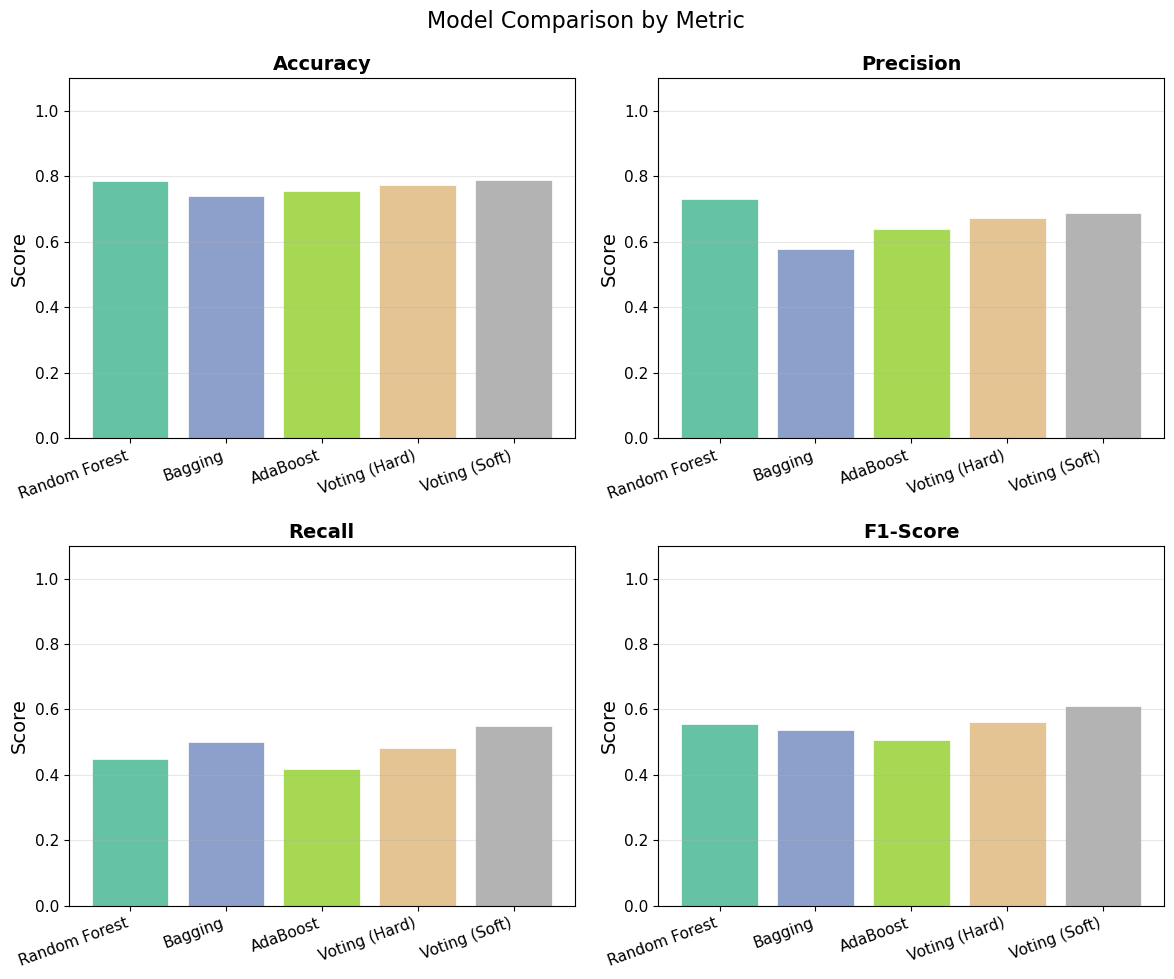

In [25]:
n_models = len(models)
colors = plt.cm.Set2(np.linspace(0, 1, n_models))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax_idx, metric in enumerate(metrics):
    ax = axes[ax_idx]
    vals = [comparison_df.loc[model, metric] for model in models]
    bars = ax.bar(range(len(models)), vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_ylim(0, 1.1)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)
fig.suptitle('Model Comparison by Metric', fontsize=16)
plt.tight_layout()
plt.show()

# Part 2 - Summary of Findings

**What I discovered during model training and evaluation:**

During model training and evaluation, I explored the performance of three ensemble models: Random Forest, Bagging, and AdaBoost, along with two ensemble techniques, Voting (Hard) and Voting (Soft). I used `GridSearchCV` to tune the hyperparameters for each individual model based on accuracy and then evaluated their performance on a test set using various metrics such as Accuracy, Precision, Recall, and F1-Score.

**How performance changed after tuning or improvements:**

*   **Random Forest** is the strongest individual model, achieving the highest accuracy of 0.785 on the test set. It also demonstrated the highest precision among all models.
*   **Bagging** and **AdaBoost** showed slightly lower performance compared to Random Forest, with accuracies of 0.740 and 0.745 respectively.
*   The **Voting Classifiers** (both Hard and Soft) showed competitive performance. Notably, **Voting (Soft)** slightly improved upon the best individual model's F1-Score, suggesting that combining the predictions of multiple models can lead to a more balanced performance, especially for potentially imbalanced datasets.

**Key insights, challenges, or lessons learned:**

*   `GridSearchCV` successfully identified optimal parameters for each model and maximized their performance within the defined search space.
*   Random Forest demonstrated strong predictive capabilities, and the Voting Classifiers highlighted the benefits of combining diverse models.
*   While accuracy is a good general measure, in scenarios like credit default prediction, recall and F1-Score (which balances precision and recall) is often a more informative metric in this case. Voting (Soft) achieved the highest F1-Score and recall.

Overall, the Random Forest and Soft Voting Classifier showed promising results for predicting credit defaults, with Soft Voting offering a slightly better balance of precision and recall.